In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Configuración para mostrar gráficos en el Notebook
%matplotlib inline

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
print("\n" + "="*55)
print("  RED NEURONAL ARTIFICIAL — Bike Sharing Dataset")
print("="*55)

df = pd.read_csv("dataset.csv")

DROP_COLS  = ["instant", "dteday", "casual", "registered", "cnt"]
TARGET_COL = "alta_demanda"

mediana_cnt = df["cnt"].median()
df[TARGET_COL] = (df["cnt"] > mediana_cnt).astype(int)

X = df.drop(columns=DROP_COLS + [TARGET_COL])
y = df[TARGET_COL]

FEATURE_NAMES = list(X.columns)
print(f"\n  Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")
print(f"  Clase 1: {y.sum()} | Clase 0: {(y==0).sum()}")


  RED NEURONAL ARTIFICIAL — Bike Sharing Dataset

  Features (11): ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
  Clase 1: 365 | Clase 0: 366


In [3]:
# 2. SPLIT TRAIN / VALIDATION / TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)
print(f"\n  Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")

# 3. ESCALADO
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)


  Train: 496  |  Val: 88  |  Test: 147


In [4]:
n_features = X_train_sc.shape[1]

modelo = Sequential([
    # Capa 1: Dense con activación ReLU + regularización
    Dense(64, activation="relu", input_shape=(n_features,),
          name="capa_entrada"),
    BatchNormalization(name="bn_1"),
    Dropout(0.3, name="dropout_1"),

    # Capa 2
    Dense(32, activation="relu", name="capa_oculta"),
    BatchNormalization(name="bn_2"),
    Dropout(0.2, name="dropout_2"),

    # Salida: Sigmoid para clasificación binaria
    Dense(1, activation="sigmoid", name="salida")
], name="RNA_BikeSharing")

modelo.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"]
)

print("\n  Arquitectura de la red:")
modelo.summary()


  Arquitectura de la red:


c:\Users\garav\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "RNA_BikeSharing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_entrada (Dense)            │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 192 (768.00 B)

In [5]:
callbacks = [
    EarlyStopping(
        monitor   = "val_loss",
        patience  = 20,
        restore_best_weights = True,
        verbose   = 1
    ),
    ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 10,
        min_lr   = 1e-5,
        verbose  = 1
    )
]

print("\n  Entrenando red neuronal...")
historia = modelo.fit(
    X_train_sc, y_train,
    validation_data = (X_val_sc, y_val),
    epochs          = 150,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)
print(f"  ✓ Entrenado en {len(historia.history['loss'])} épocas")


  Entrenando red neuronal...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5988 - loss: 0.7331 - val_accuracy: 0.6818 - val_loss: 0.6104 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7681 - loss: 0.4804 - val_accuracy: 0.7955 - val_loss: 0.5443 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8024 - loss: 0.4149 - val_accuracy: 0.8182 - val_loss: 0.4973 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8246 - loss: 0.3800 - val_accuracy: 0.8182 - val_loss: 0.4627 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8488 - loss: 0.3400 - val_accuracy: 0.7955 - val_loss: 0.4397 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8508 - loss: 0.3263 - val_accuracy: 0.8068 - val_loss: 0.4216 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 

In [6]:
y_proba = modelo.predict(X_test_sc, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)

acc  = accuracy_score(y_test,  y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test,    y_pred, zero_division=0)
f1   = f1_score(y_test,        y_pred, zero_division=0)
auc  = roc_auc_score(y_test,   y_proba)
cm   = confusion_matrix(y_test, y_pred)

print("\n" + "-"*45)
print("  MÉTRICAS EN TEST")
print("-"*45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print("-"*45)
print("\n  Reporte completo:")
print(classification_report(y_test, y_pred,
      target_names=["Baja Demanda", "Alta Demanda"]))


---------------------------------------------
  MÉTRICAS EN TEST
---------------------------------------------
  Accuracy  : 0.9252  (92.52%)
  Precision : 0.9306
  Recall    : 0.9178
  F1-Score  : 0.9241
  AUC-ROC   : 0.9706
---------------------------------------------

  Reporte completo:
              precision    recall  f1-score   support

Baja Demanda       0.92      0.93      0.93        74
Alta Demanda       0.93      0.92      0.92        73

    accuracy                           0.93       147
   macro avg       0.93      0.93      0.93       147
weighted avg       0.93      0.93      0.93       147



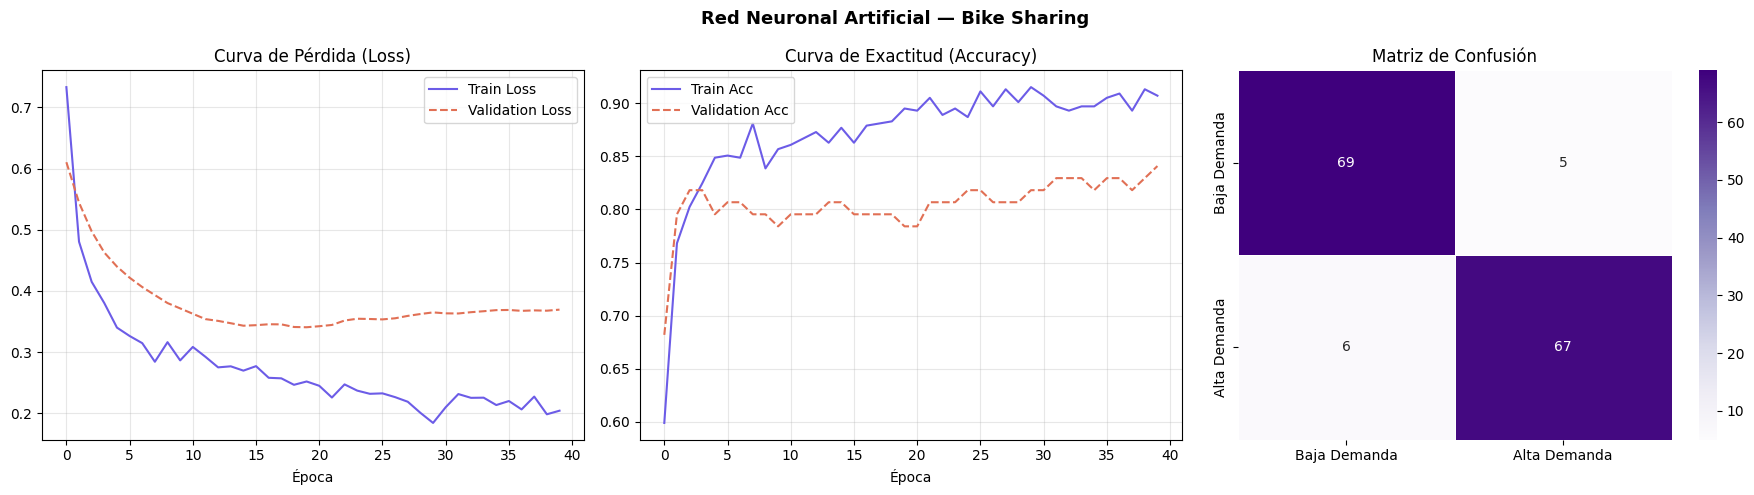

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Red Neuronal Artificial — Bike Sharing", fontsize=13, fontweight="bold")

# Loss
axes[0].plot(historia.history["loss"], label="Train Loss", color="#6c5ce7")
axes[0].plot(historia.history["val_loss"], label="Validation Loss", color="#e17055", linestyle="--")
axes[0].set_title("Curva de Pérdida (Loss)")
axes[0].set_xlabel("Época")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(historia.history["accuracy"], label="Train Acc", color="#6c5ce7")
axes[1].plot(historia.history["val_accuracy"], label="Validation Acc", color="#e17055", linestyle="--")
axes[1].set_title("Curva de Exactitud (Accuracy)")
axes[1].set_xlabel("Época")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Matriz de confusión
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Purples",
    xticklabels=["Baja Demanda", "Alta Demanda"],
    yticklabels=["Baja Demanda", "Alta Demanda"],
    ax=axes[2], linewidths=.5
)
axes[2].set_title("Matriz de Confusión")
plt.tight_layout()
plt.show()

In [8]:
modelo.save("modelo_rna.h5")
joblib.dump(scaler, "scaler_rna.pkl")

with open("feature_names.json", "w") as f:
    json.dump({
        "features"    : FEATURE_NAMES,
        "mediana_cnt" : float(mediana_cnt),
        "target_col"  : TARGET_COL
    }, f, indent=2)

print("✓ Modelo, Scaler y JSON guardados correctamente.")

✓ Modelo, Scaler y JSON guardados correctamente.
